In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import subprocess as sub
import time
from scipy.optimize import differential_evolution
from matplotlib import colors
#plt.style.use('seaborn-v0_8-whitegrid')
plt.style.use('default')
G = 6.6742e-8
C = 2.99792458e10
Msun = 1.9891e33

In [2]:
N_spins = 12
N_dens = 20
r_ratios = np.log10(np.linspace(9.9, 6, N_spins))
eoss = np.array(pd.read_csv('../compose/max_dens.csv', header=None))
eos_names = eoss[:,0]
min_dens = eoss[:,1]
max_dens = eoss[:,2]

In [2]:
sub.run('make quasik')

CompletedProcess(args='make quasik', returncode=0)

In [40]:
incl = 20
obl = 0.898196
sub.run('./quasik.exe -f "../compose/eosFPS" -e 1.209e15 -r ' + str(obl) + ' -i ' + str(incl) + ' -p 15', capture_output=True)

CompletedProcess(args='./quasik.exe -f "../eos/eosFPS" -e 1.209e15 -r 0.898196 -i 20 -p 15', returncode=0, stdout=b'EOS file: ../eos/eosFPS, Grid size = MDIVxSDIV = 151x301\r\n\r\ne_center = 1.209e15 g/cm^3\r\nr_ratio  = 0.898196\r\nMass     = 1.40016 MSUN\r\nM/R      = 0.180322 \r\nR_e      = 11.4695 km\r\nSpin     = 699.87 Hz\r\nj = a/M  = J/M^2 = 0.329649 \r\n\r\nQuadrupole: Laarakkers and Poisson \r\nQuadrupole = -5.35504e+43 g cm^2 \r\nqscale = -0.449511 \r\nmscale = -0.465692 \r\nLP formula: q = -0.467274 \r\nQuasiKerr dimensionless quadrupole parameter: epsilon = 0.340842 \r\n\r\nComparison of QuasiKerr Metric with numerical RNS metric\r\nOmega = 4397.412711, Omega_K = 11031.339171\r\n', stderr=b'')

In [3]:
MDIV = 150
cols = 6

mapdata = np.array(pd.read_csv('zmap.csv', header=None)).reshape([2*MDIV, MDIV, cols])
theta = np.arccos(mapdata[:,:,0])
phi = mapdata[:,:,1]
zos = mapdata[:,:,2]
zcon = mapdata[:,:,3]
zqk = mapdata[:,:,4]
zqkb = mapdata[:,:,5]

cmap = plt.cm.coolwarm
cmap.set_bad(color='w')

In [16]:
def zmap(zmap, vmin=None, vmax=None):

    z_mask = np.ma.masked_where(zmap == 0, zmap).transpose()

    if vmin==None:
        vmin = zmap.min()
    if vmax==None:
        vmax = zmap.max()

    plt.figure()
    plt.pcolormesh(phi.transpose(), theta.transpose(), z_mask, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.errorbar([np.pi/2, -np.pi/2], [np.pi/2, np.pi/2], xerr=np.pi/2, yerr=np.pi/2, c='k', lw=0.4)
    plt.gca().invert_yaxis()
    plt.ylabel(r"$\theta$")
    plt.xlabel(r"$\phi$")
    plt.colorbar(label="z")
    plt.savefig("out.png", dpi=390)

In [ ]:
#zmap(zos)
#zmap(zcon)
#zmap(zqk)
#zmap(zqkb)

In [ ]:
i_0 = np.where(zos != 0)
zerr_fill = (np.abs((zcon[i_0]-zos[i_0])/(zcon[i_0]+1)))*100
zerr = np.zeros(zos.shape)
zerr[i_0] = zerr_fill

zmap(zerr)

In [11]:
def zmap_3d(zmap, vmin=None, vmax=None):

    z_mask = np.ma.masked_where(zmap == 0, zmap)

    if vmin==None:
        vmin = zmap.min()
    if vmax==None:
        vmax = zmap.max()

    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    z_mask = norm(z_mask)

    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)

    fig = plt.figure(figsize=plt.figaspect(obl)*2)
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(x, y, z, rcount=2*MDIV+1, ccount=2*MDIV+1, facecolors=cmap(z_mask), shade=False)
    ax.scatter([0],[0],[1.07],c='g',s=5)
    ax.view_init(elev=90-incl, azim=0)
    ax.axis("off")
    mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    mappable.set_array(z_mask)
    fig.colorbar(mappable, shrink=0.5, ax=ax)
    ax.set_box_aspect(aspect=(1, 1, obl))
    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])
    plt.xlabel("x")
    plt.ylabel("y")
    plt.savefig("out2.png", dpi=390)

In [ ]:
#zmap_3d(zos)
#zmap_3d(zcon)
#zmap_3d(zqk)
zmap_3d(zqkb)

In [78]:
redshifts = np.array(pd.read_csv('redshift.csv'))

mu = redshifts[:,0]

z_0 = redshifts[:,1]
z_max = redshifts[:,2]
z_min = redshifts[:,3]

z_sch = redshifts[:,4]
z_grav = redshifts[:,5]

z_os_0 = redshifts[:,6]
z_os_max = redshifts[:,7]
z_os_min = redshifts[:,8]
gamma = redshifts[:,9]

z_0_max = redshifts[:,14]
z_0_min = redshifts[:,15]

z_schv = 1/redshifts[:,10]-1
z_ker = 1/redshifts[:,11]-1
z_quk = 1/redshifts[:,12]-1
z_quk_bad = 1/redshifts[:,13]-1

In [ ]:
fig, ax = plt.subplots()
ax.plot(mu, z_0, c='k', alpha=0.3, lw=3, label='RNS')
#ax.plot(mu, z_sch, c='m', alpha=0.7, label='Schwarzschild')
#ax.plot(mu, z_grav, c='c', alpha=0.7, label='$ RNS \ g_{tt}$')
ax.plot(mu[:-1], z_os_0[:-1], c='b', alpha=0.7, label='Oblate Schwarzschild')
#ax.plot(mu, z_schv, c='brown', alpha=0.7, label='$Sch/\gamma$')
ax.plot(mu, z_ker, c='g', alpha=0.7, label='Kerr')
ax.plot(mu, z_quk, c='r', alpha=1, lw=2.2, linestyle=':', label='Quasikerr')
#ax.plot(mu, z_quk_bad, c='orange', alpha=1, lw=1, linestyle='--', label='Incorrect Quasikerr')
plt.xlabel(r"$\cos\theta$")
plt.ylabel('z')
#ax.set_ylim(0, 0.3)
ax.legend(loc='best')
#plt.savefig('output.png', dpi=390)

In [ ]:
fig, ax = plt.subplots()
ax.plot(mu, z_0, c='k', alpha=0.7, label=r'RNS $b_z=0$')
ax.plot(mu, z_max, c='b', alpha=0.7, label=r'RNS $b_z=b_{z,max}$')
ax.plot(mu, z_min, c='r', alpha=0.7, label=r'RNS $b_z=b_{z,min}$')
ax.plot(mu, z_os_0, c='g', alpha=0.7, label=r'Obl Sch $b=0$')
#ax.plot(mu, z_os_max, c='c', alpha=0.7, label=r'Obl Sch $b=b_{max}$')
#ax.plot(mu, z_os_min, c='orange', alpha=0.7, label=r'Obl Sch $b=b_{min}$')
ax.plot(mu, z_0_max, c='m', alpha=0.7, label=r'Empirical $b=b_{max}$')
ax.plot(mu, z_0_min, c='pink', alpha=0.7, label=r'Empirical $b=b_{min}$')
#ax.plot(mu, z_quk_bad, c='orange', alpha=1, lw=1, linestyle='--', label='Incorrect Quasikerr')

plt.xlabel(r'$\cos\theta$')
plt.ylabel('z')
#ax.set_ylim(0, 0.3)
ax.legend(prop={'size':8})
plt.savefig('bextreme_const.png', dpi=390)

------------------------------------------------------------------------------------------------------------------------------------------------------

In [3]:
class Eos_Set():

    def __init__(self, eos_name):

        self.name = eos_name
        self.data = np.load("star_data_"+eos_name+'.npy')
        
    def z_model(self, M_R, spin, C):

        return 1/np.sqrt(1-2*M_R)*(1+C*spin**2)-1

    def C(self, M_R, c1, c2):

        return c1*M_R**2+c2*M_R

    def z_total(self, i_r):

        M_R = self.data[:, i_r, 4]
        z_total = self.data[:, i_r, 6]

        return [M_R, z_total]
    
    def z_empirical(self, i_r, c1, c2):

        M_R = self.data[:, i_r, 4]
        spins = self.data[:, i_r, 5]
        z_emp = self.z_model(M_R, spins, self.C(M_R, c1, c2))

        return [M_R, z_emp]
    
    def z_quad(self, i_r):

        M_R = self.data[:, i_r, 4]
        a = self.data[:, i_r, 8]
        eps = self.data[:, i_r, 9]

        omega = self.data[:, i_r, 1]
        R = self.data[:, i_r, 2]/100
        V = omega*R/C

        q = -eps-a**2

        z_q = 1/np.sqrt(1-2*M_R)*(1-q*M_R**3)-1

        return z_q
    
    def filter_index(self, i_r):

        massrange = np.array([0.9, 2.4])*Msun
        #spinrange = 800*2*np.pi
        mrrange = np.array([0.05, 1])

        indices = np.where(
        (self.data[:, i_r, 3] > massrange[0]) & 
        (self.data[:, i_r, 3] < massrange[1]) & 
        #(self.data[:, i_r, 1] < spinrange) & 
        (self.data[:, i_r, 4] > mrrange[0]) &
        (self.data[:, i_r, 4] < mrrange[1])
        )[0]
        indices = np.unique(indices)
        indices.sort()
        return indices.astype(int)
    
    def test_fit(self, c1, c2, filter=True, show=False):

        if show:
            filter = False

        redshift_error = np.empty([0])

        for j in range(6):

            i_ = range(N_dens)
            if filter:
                i_ = self.filter_index(j)
            z_t = self.data[i_, j, 6]
            mr = self.data[i_, j, 4]
            spn = self.data[i_, j, 5]
            z_e = self.z_model(mr, spn, self.C(mr, c1, c2))

            z_err = np.abs(z_e-z_t)/(1+z_t)

            redshift_error = np.concatenate([redshift_error, z_err])

        residual = np.sum(redshift_error**2)

        if (show):

            M_R = np.zeros(N_dens+1)
            M_R[1:] = self.data[:, 5, 4]
            r_r = np.zeros(N_spins+1)
            r_r[0] = 1
            r_r[1:] = r_ratios

            plt.figure()
            plt.pcolormesh(M_R, r_r, redshift_error.transpose()*100, cmap='plasma', vmin=0, shading='flat')
            plt.colorbar(label='squared residual')
            plt.xlabel('$M/R$')
            plt.ylabel('$r_{e}/r_{p}$')
            plt.title("eos"+self.name)
            plt.show()

            print("error = "+str(residual))

        return residual

    def plot_fit(self, c1, c2, i_r):

        M_R = self.data[:, i_r, 4]
        spins = self.data[:, i_r, 5]
        z_total = self.data[:, i_r, 6]
        z_emp = self.z_model(M_R, spins, self.C(M_R, c1, c2))
        a = self.data[:, i_r, 8]
        eps = self.data[:, i_r, 9]

        q = -eps-a**2

        z_q = self.z_quad(i_r)

        skip = 2
        plt.figure()
        plt.plot(M_R[skip:], z_total[skip:], c='r', alpha=0.7, label='total redshift')
        plt.plot(M_R[skip:], z_emp[skip:], c='g', alpha=0.5, label='empirical redshift')
        plt.plot(M_R[skip:], z_q[skip:], c='m', alpha=0.7, label='q redshift')
        plt.xlabel('$M/R$')
        plt.ylabel('z_eq')
        plt.title("eos "+self.name+", $r_e/r_p = $"+str(r_ratios[i_r]))
        plt.legend()
        plt.show()
    
    def fit_LSQ(self):

        x = np.empty([0,2])
        y = np.empty([0])

        for i_r in range(N_spins):
            
            i_ = self.filter_index(i_r)
            mr = self.data[i_, i_r, 4]
            spn = self.data[i_, i_r, 5]
            z = self.data[i_, i_r, 6]

            xfill = np.array([mr, mr**2]).transpose()
            yfill = (1/spn**2)*((1+z)*np.sqrt(1-2*mr)-1)

            x = np.concatenate([x, xfill])
            y = np.concatenate([y, yfill])


        xT = np.transpose(x)
        xTx = np.dot(xT, x)
        xTxinv = np.linalg.inv(xTx)
        A = np.dot(xTxinv, xT)
        coefs = np.dot(A, y)
        
        return coefs
    
    def bruteforce(self):
        steps = 50
        c1_range = np.linspace(0, 3, steps)
        c2_range = np.linspace(0, 1, steps)
        fit_errors = np.zeros([steps, steps])

        for ic1 in range(steps):
            for ic2 in range(steps):
                fit_errors[ic1, ic2] = self.test_fit(c1_range[ic1], c2_range[ic2])
        min = fit_errors.min()
        indices = np.where(fit_errors == min)
        c1 = c1_range[indices[0]][0]
        c2 = c2_range[indices[1]][0]
        coefs = np.array([c2, c1])

        plt.figure()
        plt.imshow(fit_errors)
        plt.xlabel('c1 from 0 to 3')
        plt.ylabel('c2 from 0 to 1')
        plt.colorbar(label='residuals')

        return coefs
    
    def diff_evo_obj(self, params):

        c1, c2 = params
        return self.test_fit(c1, c2)
    
    def diff_evo(self):

        bounds = [(0.8, 1.8), (0.4, 0.6)]
        result = differential_evolution(self.diff_evo_obj, bounds)
        c1, c2 = result.x
        coefs = np.array([c2, c1])

        return coefs 

    def plot_quad_(self, i_r, eta=3.3):

        M = self.data[self.filter_index(i_r), i_r, 3]
        #R = self.data[self.filter_index(i_r), i_r, 2]
        M_R = self.data[self.filter_index(i_r), i_r, 4]
        #quad = self.data[self.filter_index(i_r), i_r, 7]
        a = self.data[self.filter_index(i_r), i_r, 8]
        eps = self.data[self.filter_index(i_r), i_r, 9]

        q = -eps-a**2
        
        quad_corr = a**2*(1+eta)

        skip = 0
        plt.figure()
        plt.plot(M[skip:]/Msun, quad_corr[skip:], label='$a^2(1+3.3)$ ')#+str(r_ratios[i_r]))
        plt.plot(M[skip:]/Msun, -q[skip:], label='q ')#+str(r_ratios[i_r]))
        
        plt.xlabel('$M/M_\odot$')
        plt.ylabel('dimensionless q')
        plt.title("eos "+self.name+", $r_p/r_e$ = "+str(r_ratios[i_r]))
        plt.legend()

        plt.show()

    def plot_quad(self, i_r):

        M = self.data[self.filter_index(i_r), i_r, 3]
        M_R = self.data[self.filter_index(i_r), i_r, 4]
        a = self.data[self.filter_index(i_r), i_r, 8]
        eps = self.data[self.filter_index(i_r), i_r, 9]
        spn = self.data[self.filter_index(i_r), i_r, 5]
        zperr = self.data[self.filter_index(i_r), i_r, 10]

        q = -eps-a**2

        skip = 0
        plt.figure()
        #plt.plot(M_R[skip:], -q[skip:], label='q')#+str(r_ratios[i_r]))
        #plt.plot(M_R[skip:], (self.C(M_R, 1.3, 0.5)*M_R**(-3)*spn**2)[skip:], label='approx')
        plt.plot(M_R[skip:], np.abs(zperr[skip:])*100, c='r', label='z_pole error')
        
        plt.xlabel('$M/R$')
        plt.ylabel('q')
        plt.title("eos "+self.name+", $r_p/r_e$ = "+str(r_ratios[i_r]))
        plt.legend()

        plt.show()

In [4]:
Eos_array = np.empty(eos_names.size, dtype=object)

for j in range(eos_names.size):

    Eos_array[j] = Eos_Set(eos_names[j])

Eos_real = np.empty(22, dtype=object)

for j in range(22):

    Eos_real[j] = Eos_Set(eos_names[j])

Eos_poly = np.empty(10, dtype=object)

for j in range(10):

    Eos_poly[j] = Eos_Set(eos_names[j+22])

In [ ]:
for Eos in Eos_array:

    for i_r in range(N_spins):
    #Eos.plot_fit(1.16, 0.52, 4)
        Eos.plot_quad(i_r)

In [20]:
res_ls = 0
res_de = 0

for Eos in Eos_array:
    try:
        coefs_ls = Eos.fit_LSQ()
    except np.linalg.LinAlgError:
        print('error: eos'+Eos.name)
        continue
    coefs_de = Eos.diff_evo()
    #res_o += Eos.test_fit(coefs_o[1], coefs_o[0])
    res_ls += Eos.test_fit(coefs_ls[1], coefs_ls[0])
    res_de += Eos.test_fit(coefs_de[1], coefs_de[0])

#print("brute force residuals = ", res_o)
print("LSQ residuals = ", res_ls)
print("differential evolution residuals = ", res_de)


error: eosB
error: eosG
LSQ residuals =  0.0019030497409941493
differential evolution residuals =  0.0005758081712866198


In [69]:
res_ls = 0
res_de = 0
res_r = 0

for Eos in Eos_real:

    res_ls += Eos.test_fit(0.96, 0.55, True)
    res_de += Eos.test_fit(1.16, 0.52, True)
    res_r += Eos.test_fit(1.1, 0.53, True)

print("LSQ residuals =  ", res_ls)
print("differential evolution residuals = ", res_de)
print(res_r)

LSQ residuals =   0.0008004396165630079
differential evolution residuals =  0.0003113612509713502
0.00036541436074186075


In [13]:
def plot_3derror(Eos_array):

    colors = np.array(['r', 'g', 'b', 'y', 'c', 'm', 'orange'])
    fig = plt.figure(figsize=plt.figaspect(0.9)*2)
    ax = fig.add_subplot(projection='3d')

    M_R = np.empty([0])
    spins = np.empty([0])
    zp_err = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.data[eos.filter_index(i_r), i_r, 4]
            spn = eos.data[eos.filter_index(i_r), i_r, 5]
            zpe = np.abs(eos.data[eos.filter_index(i_r), i_r, 10])*100

            ax.scatter(mr, spn**2, zpe, color=colors[i_r], alpha=0.3, s=5)

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            zp_err = np.concatenate([zp_err, zpe])

    ax.view_init(elev=15, azim=-110)
    ax.set_box_aspect(aspect=(1, 1, 1))
    font=8
    ax.tick_params(labelsize=font, pad=-2)
    ax.tick_params(axis='z', labelsize=font, pad=2)
    ax.set_xlabel("M/R", labelpad=0)
    ax.set_ylabel("$\overline{\Omega}^{\ 2}$", labelpad=0)
    ax.set_zlabel("$\delta z \ (\%)$", labelpad=0)

    custom_lines = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], markersize=5, alpha=0.5, label=f'$\sigma_r$ = {r_ratios[i]}') for i in range(N_spins)]
    ax.legend(handles=custom_lines)
    plt.savefig("3d_error.png", dpi=390)

In [ ]:
plot_3derror(Eos_real)

In [27]:
def plot_3dredshifts(Eos_array):

    colors = np.array(['r', 'g', 'b', 'y', 'c', 'm', 'orange'])
    fig = plt.figure(figsize=plt.figaspect(0.9)*2)
    ax = fig.add_subplot(projection='3d')

    M_R = np.empty([0])
    spins = np.empty([0])
    z_eq = np.empty([0])

    xis=0
    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.data[eos.filter_index(i_r), i_r, 4]
            spn = eos.data[eos.filter_index(i_r), i_r, 5]
            z = (eos.data[eos.filter_index(i_r), i_r, 6]+1)*np.sqrt(1-2*mr)-1

            ax.scatter(mr, spn**2, z, alpha=0.3, s=5)

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            z_eq = np.concatenate([z_eq, z])
            zemp = 1/np.sqrt(1-2*mr)*(1+spn**2*(1.15*mr**2+0.52*mr))-1
            xis += np.sum(((z-zemp))**2)

    M_R_mesh, spins_mesh = np.meshgrid(np.sort(M_R), np.sort(spins))
    #z_emp = 1/np.sqrt(1-2*M_R_mesh)*(1+spins_mesh**2*(1.15*M_R_mesh**2+0.52*M_R_mesh))-1
    z_emp = (1+spins_mesh**2*(1.15*M_R_mesh**2+0.52*M_R_mesh))-1

    print(xis)
    print(z_eq.size)

    ax.plot_surface(M_R_mesh, spins_mesh**2, z_emp, color=colors[-1], alpha=0.3)
    ax.view_init(elev=15, azim=0)
    ax.set_box_aspect(aspect=(1, 1, 1))
    font=11
    ax.tick_params(labelsize=font, pad=1)
    ax.tick_params(axis='z', labelsize=font, pad=4)
    ax.set_xlabel("M/R", labelpad=2)
    ax.set_ylabel("$\overline{\Omega}^{\ 2}$", labelpad=2)
    ax.set_zlabel("$z_{b=0}/z_0$", labelpad=4)

    custom_lines = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], markersize=5, alpha=0.5, label=f'$\sigma_r$ = {r_ratios[i]}') for i in range(N_spins)]
    custom_lines.append(plt.Line2D([0], [0], lw=4, alpha=0.3, label='empirical redshift'))
    ax.legend(handles=custom_lines)
    plt.savefig("3d_z.png", dpi=390)

708.1309697828752
4935


IndexError: index 7 is out of bounds for axis 0 with size 7

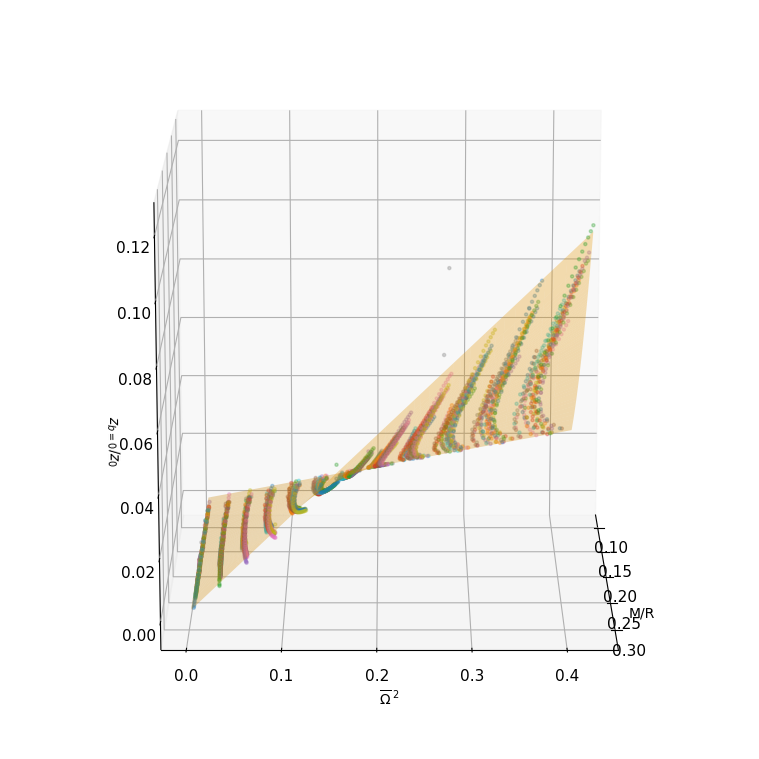

In [28]:
plot_3dredshifts(Eos_real)

In [14]:
def plot_correction(Eos_array):

    colors = np.array(['r', 'g', 'b', 'y', 'c', 'm', 'orange'])
    fig = plt.figure(figsize=plt.figaspect(0.9)*2)
    ax = fig.add_subplot(projection='3d')

    M_R = np.empty([0])
    spins = np.empty([0])
    z_eq = np.empty([0])

    xis=0
    for i_r in range(N_spins-8):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.data[eos.filter_index(i_r), i_r, 4]
            spn = eos.data[eos.filter_index(i_r), i_r, 5]
            z = eos.data[eos.filter_index(i_r), i_r, 6]

            c = (1/spn**2)*((1+z)*np.sqrt(1-2*mr)-1)
            ax.scatter(mr, spn**2, c,  alpha=0.3, s=8)

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            z_eq = np.concatenate([z_eq, z])
            cf = 1.15*mr**2-0.52*mr
            xis += np.sum((c-cf)**2)
    
    M_R_mesh, spins_mesh = np.meshgrid(np.sort(M_R), np.sort(spins))
    c_emp =1.15*M_R_mesh**2+0.52*M_R_mesh

    print(xis)
    print(z_eq.size)

    ax.plot_surface(M_R_mesh, spins_mesh**2, c_emp, color=colors[-1], alpha=0.3)
    ax.view_init(elev=15, azim=-110)
    ax.set_box_aspect(aspect=(1, 1, 1))
    font=8
    ax.tick_params(labelsize=font, pad=-2)
    ax.tick_params(axis='z', labelsize=font, pad=5)
    ax.set_xlabel("M/R", labelpad=-5)
    ax.set_ylabel("$\overline{\Omega}^{\ 2}$", labelpad=-5)
    ax.set_zlabel(r"$1/\overline{\Omega}^{\ 2} \ \left( (1+z_0)\sqrt{1-2M/R}-1 \right)$", labelpad=8)

    custom_lines = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], markersize=5, alpha=0.5, label=f'$\sigma_r$ = {r_ratios[i]}') for i in range(N_spins)]
    custom_lines.append(plt.Line2D([0], [0],  lw=4, alpha=0.3, label='correction term'))
    ax.legend(handles=custom_lines)
    plt.savefig("3d_higher.png", dpi=390)

In [12]:
r_ratios

array([0.99563519, 0.97979661, 0.96335847, 0.94627358, 0.92848896,
       0.90994483, 0.89057343, 0.87029747, 0.84902833, 0.82666368,
       0.80308449, 0.77815125])

84.0233932287936
1682


IndexError: index 7 is out of bounds for axis 0 with size 7

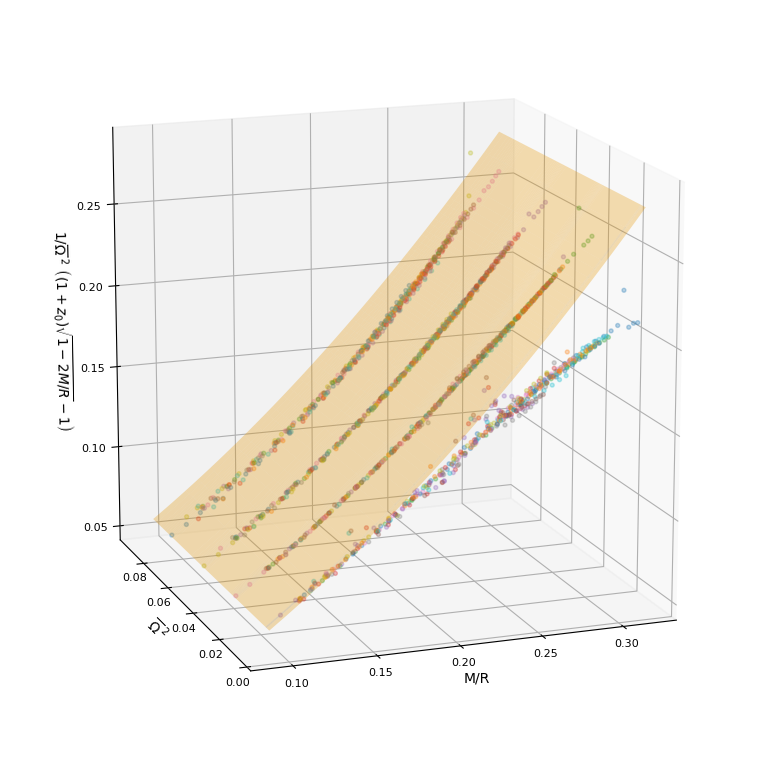

In [15]:
plot_correction(Eos_real)

In [6]:
def fit_LSQ_all(Eos_array, show=True):

    x = np.empty([0,2])
    y = np.empty([0])
    M = np.empty([0])
    omeg = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            mr = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 4]
            spn = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 5]
            z = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 6]
            Mfill = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 3]/Msun
            omegfill = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 1]/(2*np.pi)

            xfill = np.array([mr, mr**2]).transpose()
            yfill = (1/spn**2)*((1+z)*np.sqrt(1-2*mr)-1)

            x = np.concatenate([x, xfill])
            y = np.concatenate([y, yfill])
            M = np.concatenate([M, Mfill])
            omeg = np.concatenate([omeg, omegfill])

    xT = np.transpose(x)
    xTx = np.dot(xT, x)
    xTxinv = np.linalg.inv(xTx)
    A = np.dot(xTxinv, xT)
    coefs = np.dot(A, y)

    if (show):
        plt.scatter(x[:,0], y, s=2, c='b', alpha=0.3, label='data')
        xs = x[:,0]
        xs = np.sort(xs, None)
        plt.plot(xs, 1.05*xs**2+0.54*xs, c='r', lw=1.7, alpha=0.6, label='differential evolution')
        plt.plot(xs, coefs[1]*xs**2+coefs[0]*xs, c='m', lw=1.7, alpha=0.6, label='LSQ fit')
        #plt.plot(xs, 1/2*xs*(1+2*xs)*(1+0.33*xs), c='k', lw=1.7, alpha=0.6, label='one parameter')
        #plt.plot(xs, 1/2*xs*(1+2.5*xs), c='orange', lw=1.7, alpha=0.6, label='one parameter')
        plt.xlabel('M/R')
        plt.ylabel('$1/\overline{\Omega}^2 ((1+z)\sqrt{1-2M/R)}-1)$')
        plt.legend()
        plt.savefig("scatter.png", dpi=390)


    plt.figure()
    plt.hist(xs, 30, rwidth=0.8)
    plt.xlabel("M/R")
    #plt.savefig("hist1.png", dpi=390)

    plt.figure()
    plt.hist(M, 30, rwidth=0.8)
    plt.xlabel("$M/M_\odot$")
    #plt.savefig("hist2.png", dpi=390)

    plt.figure()
    plt.hist(omeg, 30, rwidth=0.8)
    plt.xlabel("f (Hz)")
    #plt.savefig("hist3.png", dpi=390)
    
    return coefs

array([0.5718963 , 0.82046348])

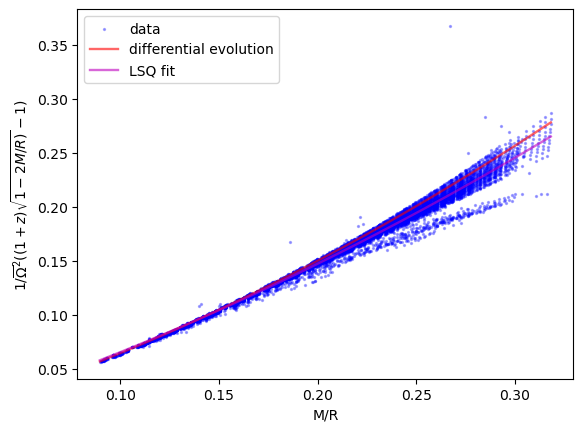

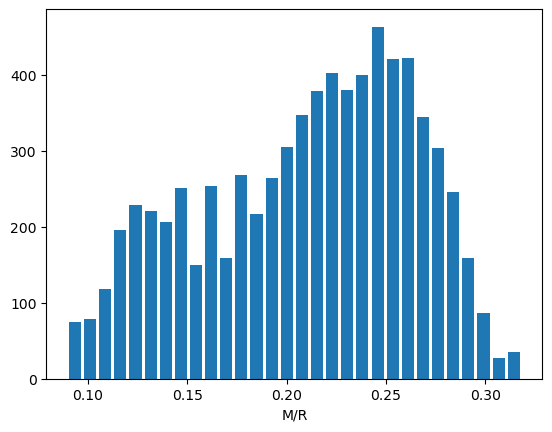

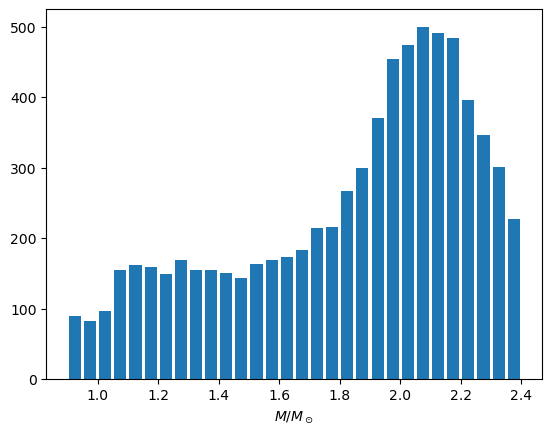

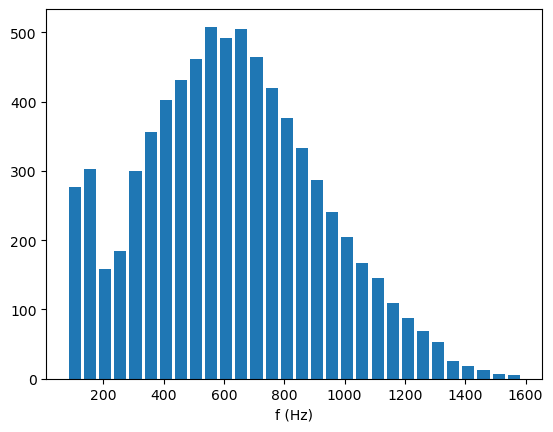

In [7]:
fit_LSQ_all(Eos_array)

In [ ]:
fit_LSQ_all(Eos_real)

In [ ]:
fit_LSQ_all(Eos_poly)

In [23]:
def diff_evo_all_obj(params, Eos_array):

    c1, c2 = params

    z_t = np.empty([0])
    z_e = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            mr = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 4]
            spn = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 5]

            z_t_fill = Eos_array[i_s].data[Eos_array[i_s].filter_index(i_r), i_r, 6]
            z_e_fill = (1/np.sqrt(1-2*mr))*(1+spn**2*(c1*mr**2+c2*mr))-1

            z_t = np.concatenate([z_t, z_t_fill])
            z_e = np.concatenate([z_e, z_e_fill])

    residual = np.sum(((z_t-z_e)/(1+z_t))**2)

    return residual

def diff_evo_all(Eos_array):

    bounds = [(0, 5), (0, 5)]
    result = differential_evolution(diff_evo_all_obj, bounds, args=(Eos_array,))
    c1, c2 = result.x
    coefs = np.array([c2, c1])

    return coefs

In [24]:
diff_evo_all(Eos_array)

array([0.53949332, 1.04618015])

In [68]:
diff_evo_all(Eos_real)

array([0.52054962, 1.16889235])

In [69]:
diff_evo_all(Eos_poly)

array([0.53148679, 1.11914931])

In [7]:
def create_dataset(i):
    
    eos = eos_names[i]
    e_min = min_dens[i]
    e_max = max_dens[i]
    ratios = r_ratios
    densities = np.linspace(e_min, e_max, N_dens)

    star_data = np.zeros([N_dens, N_spins, 11])
    i_r=0
    t_0 = time.time()
    for r in ratios:
        i_e = 0
        for e in densities:
            string = 'quasik.exe -f "../compose/eos' + eos + '" -e ' + "{:e}".format(e).replace('+', '') + ' -r ' + str(r)
            sub.run(string)
            output = np.loadtxt('star.csv', delimiter=',')
            star_data[i_e,i_r,:] = output
            print(eos+'  %i, %i ' % (i_r+1, i_e+1), end='\r')
            i_e += 1
        i_r += 1
    np.save('star_data_'+eos, star_data)
    t_f = time.time()
    t_min = round((t_f-t_0)/60, 2)
    print(eos+' done in '+str(t_min)+' minutes')
    return

In [ ]:
for i in range(eos_names.size):
    try:
        create_dataset(i)
    except ValueError:
        print(str(eos_names[i])+' failed due to ValueError')
    except TypeError:
        print(str(eos_names[i])+' failed due to TypeError')
    except Exception:
        print(str(eos_names[i])+' failed due to Exception')

APR done in 19.0 minutes
BBB done in 15.0 minutes
BLC done in 11.27 minutes
CMF1 done in 12.0 minutes
CMF1H done in 12.64 minutes
CMF2 done in 12.05 minutes
D1MStar done in 12.29 minutes


DDHdY4 done in 14.12 minutes
DDMEX done in 10.53 minutes
GDFMI done in 11.6 minutes
GDFMII done in 10.36 minutes
GM1 done in 13.22 minutes
KDE0v done in 14.38 minutes
M3 done in 12.25 minutes


NL3 done in 9.62 minutesf "../compose/eosNL3" -e 7.500000e14 -r 0.7781512503836436


PCSB2 done in 10.19 minutes
PKDD done in 10.66 minutes
QHC21A done in 12.37 minutes
QMCRMF3 done in 13.68 minutes
Rs done in 15.52 minutes
SK255 done in 14.58 minutes
Ska done in 12.88 minutes
TW done in 13.79 minutes
Pol0 done in 11.94 minutes
Pol1 done in 11.21 minutes
Pol2 done in 11.97 minutes
Pol3 done in 13.86 minutes
Pol4 done in 12.93 minutes
Pol5 done in 12.58 minutes
Pol6 done in 11.95 minutes
Pol7 done in 13.07 minutes
Pol8 done in 10.96 minutes
Pol9 done in 12.92 minutes
